In [104]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error

In [105]:
df = pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [106]:
#target = 'class'
num_features = []
cat_features = []
for col in df.columns:
#    if col == target: continue
    if df[col].dtype == "str":
        cat_features.append(col)
    else: 
        num_features.append(col)
print(num_features)
print(cat_features)

[]
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [108]:
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "str":
        encoder.fit(df[col])
        df[col]= encoder.fit_transform(df[col])
df.head()

#df = pd.get_dummies(df, columns=cat_features, dtype=int)
#df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [109]:
df[df.isnull().any(axis=1)]
df = df.dropna()
df.shape

(8124, 23)

In [110]:
target = 'class'
X = df.drop(target, axis=1)
y = df[target]

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=37, weights='uniform', p=10)
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print('Train Accuracy:', accuracy_score(y_train, y_pred_train), 'Test Accuracy:', accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Train MSE: ', mse_train)
print('Test MSE: ', mse_test)
print('R^2 = ', knn.score(X_test, y_test))

Train Accuracy: 0.9550700107708878 Test Accuracy: 0.9458461538461539
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       843
           1       0.98      0.90      0.94       782

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Train MSE:  0.04492998922911217
Test MSE:  0.05415384615384616
R^2 =  0.9458461538461539


In [114]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=100, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print('Train Accuracy:', accuracy_score(y_train, y_pred_train), 'Test Accuracy:', accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Train MSE: ', mse_train)
print('Test MSE: ', mse_test)
print('R^2 = ', lr.score(X_test, y_test))

Train Accuracy: 0.9547622711186337 Test Accuracy: 0.9501538461538461
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       843
           1       0.95      0.95      0.95       782

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Train MSE:  0.04523772888136637
Test MSE:  0.049846153846153846
R^2 =  0.9501538461538461


c:\Users\kcoli\Documents\ml2026\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Accuracy: 0.9899984613017387 Test Accuracy: 0.9907692307692307
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       843
           1       1.00      0.98      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625

Train MSE:  0.01000153869826127
Test MSE:  0.009230769230769232
R^2 =  0.9907692307692307


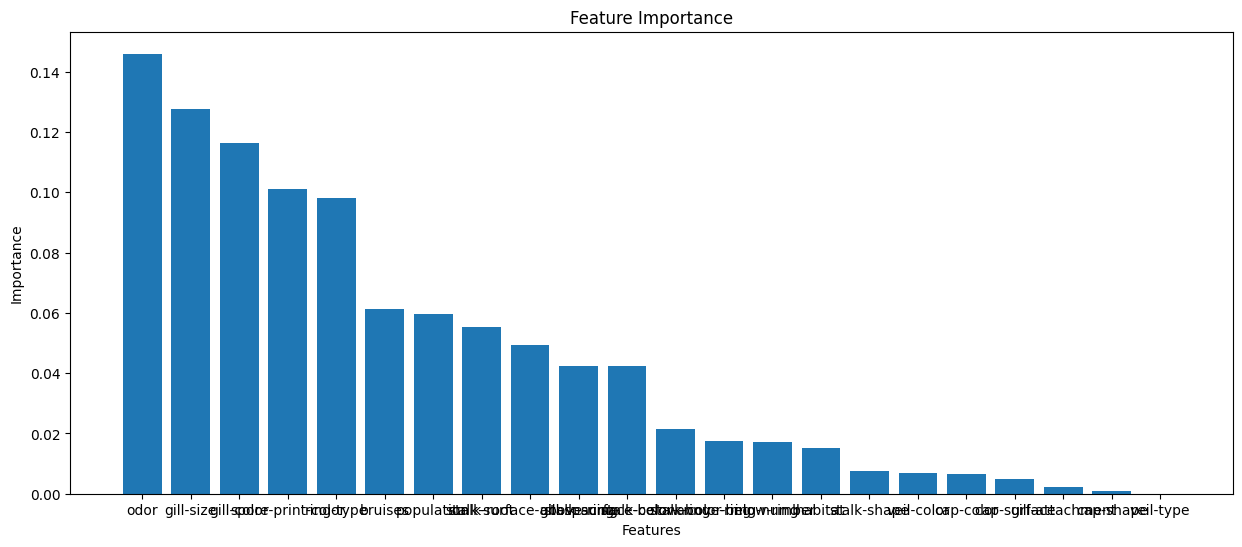

In [115]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=60, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print('Train Accuracy:', accuracy_score(y_train, y_pred_train), 'Test Accuracy:', accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Train MSE: ', mse_train)
print('Test MSE: ', mse_test)
print('R^2 = ', rf.score(X_test, y_test))

# Feature Importance:
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': rf.feature_importances_}).sort_values('Gini Importance', ascending=False)

plt.figure(figsize=(15, 6))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Gini Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()


Train Accuracy: 0.9929219879981536 Test Accuracy: 0.9938461538461538
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       843
           1       1.00      0.99      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625

Train MSE:  0.007078012001846438
Test MSE:  0.006153846153846154
R^2 =  0.9938461538461538


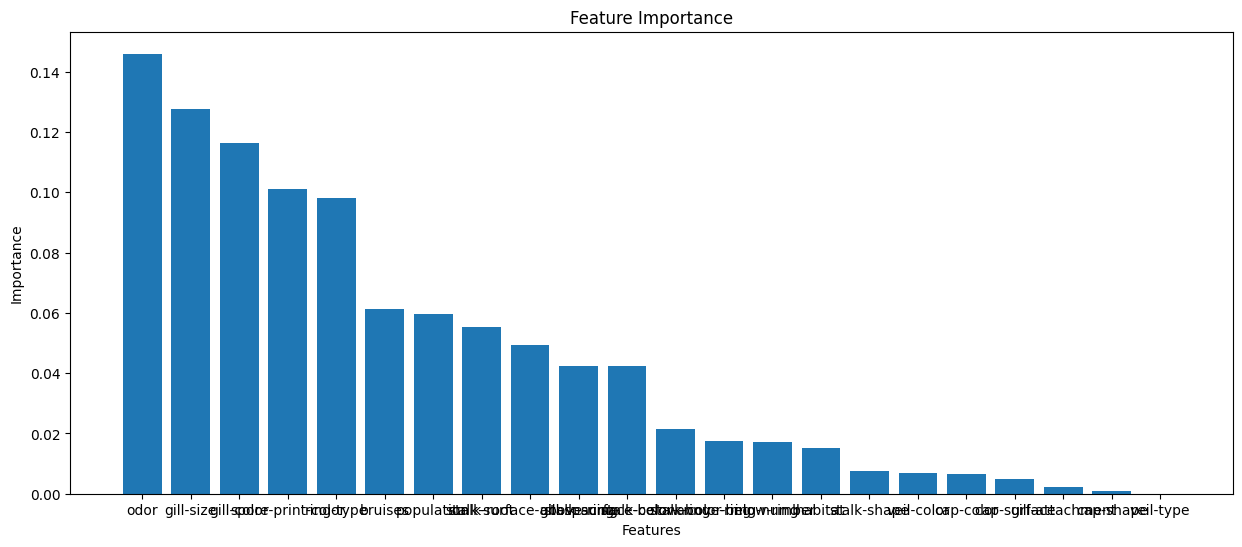

In [117]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print('Train Accuracy:', accuracy_score(y_train, y_pred_train), 'Test Accuracy:', accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Train MSE: ', mse_train)
print('Test MSE: ', mse_test)
print('R^2 = ', xgb_model.score(X_test, y_test))

# Feature Importance:
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': rf.feature_importances_}).sort_values('Gini Importance', ascending=False)

plt.figure(figsize=(15, 6))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Gini Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

In [173]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
X_train_tensor = torch.from_numpy(X_train.values.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.values.astype(np.float32)).unsqueeze(1)
X_test_tensor = torch.from_numpy(X_test.values.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.values.astype(np.float32)).unsqueeze(1)


In [174]:
class simpleNN(nn.Module):
    def __init__(self):
        super(simpleNN, self).__init__()
        self.layer1 = nn.Linear(22,500)
        self.layer2 = nn.Linear(500,1)

    def forward(self, X_train_tensor):
        z1 = self.layer2(F.relu(self.layer1(X_train_tensor)))
        return z1
model = simpleNN()

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.001)

In [193]:
for epoch in range(10): # Train for 100 iterations
    optimizer.zero_grad() # Reset gradients before new calculation
    # Forward pass
    y_pred = model(X_train_tensor) # Compute predictions
    # Compute loss
    loss = criterion(y_pred, y_train_tensor)
    # Backward pass (compute gradients)
    loss.backward() # Backpropagate error
    # Update weights
    optimizer.step() # Apply weight updates
    # Print loss every 20 epochs
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')


Epoch 0, Loss: 0.0656
Epoch 5, Loss: 0.0655


In [194]:
model.eval()
with torch.no_grad():
    train_output = model(X_train_tensor)
    test_output = model(X_test_tensor)
    mse_train = criterion(train_output, y_train_tensor)
    mse_test = criterion(test_output, y_test_tensor)
    train_pred = (torch.sigmoid(train_output) >= 0.5).float()
    test_pred = (torch.sigmoid(test_output) >= 0.5).float()
    train_acc = (train_pred == y_train_tensor).float().mean()
    test_acc = (test_pred == y_test_tensor).float().mean()

print('Train accuracy: ', train_acc.item())
print('Test accuracy: ', test_acc.item())
print('Train MSE: ', mse_train.item())
print('Test MSE: ', mse_test.item())

Train accuracy:  0.5750115513801575
Test accuracy:  0.5778461694717407
Train MSE:  0.0653817430138588
Test MSE:  0.06950580328702927
